# Optuna Search Results Visualization
DML Graph structure search on CIFAR-100

In [1]:
import optuna
from graphviz import Digraph

optuna.logging.set_verbosity(optuna.logging.WARNING)

/workspace/deep-mutual-learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Study

In [2]:
STUDY_NAME = "dml_search"
STORAGE   = "sqlite:///optuna.db"
MAIN_MODEL = "resnet32"  # node 0 fixed model

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
)

complete = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned   = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

print(f"Total trials     : {len(study.trials)}")
print(f"Complete trials  : {len(complete)}")
print(f"Pruned trials    : {len(pruned)}")

if complete:
    print(f"Best value       : {study.best_value:.4f}  (trial #{study.best_trial.number})")
    print("Best params      :")
    for k, v in study.best_trial.params.items():
        print(f"  {k}: {v}")
else:
    print("No complete trials yet.")

Total trials     : 3
Complete trials  : 2
Pruned trials    : 0
Best value       : 73.1600  (trial #0)
Best params      :
  model_1: resnet32
  model_2: wideresnet28_2
  model_3: resnet32
  model_4: resnet32
  model_5: resnet32
  model_6: resnet110
  label_edge_0: True
  label_edge_1: True
  label_edge_2: False
  label_edge_3: False
  label_edge_4: True
  label_edge_5: False
  label_edge_6: False
  peer_0_1: False
  peer_0_2: False
  peer_0_3: False
  peer_0_4: True
  peer_0_5: False
  peer_0_6: True
  peer_1_0: False
  peer_1_2: True
  peer_1_3: False
  peer_1_4: False
  peer_1_5: False
  peer_1_6: False
  peer_2_0: False
  peer_2_1: False
  peer_2_3: False
  peer_2_4: True
  peer_2_5: False
  peer_2_6: True
  peer_3_0: True
  peer_3_1: True
  peer_3_2: True
  peer_3_4: False
  peer_3_5: False
  peer_3_6: True
  peer_4_0: True
  peer_4_1: False
  peer_4_2: False
  peer_4_3: False
  peer_4_5: False
  peer_4_6: True
  peer_5_0: True
  peer_5_1: True
  peer_5_2: True
  peer_5_3: False
  p

--- Rank 1  trial #0  val_acc=73.1600 ---


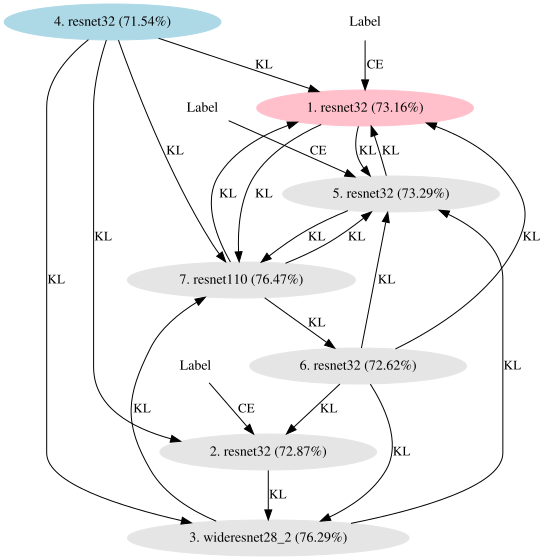

--- Rank 2  trial #1  val_acc=67.8200 ---


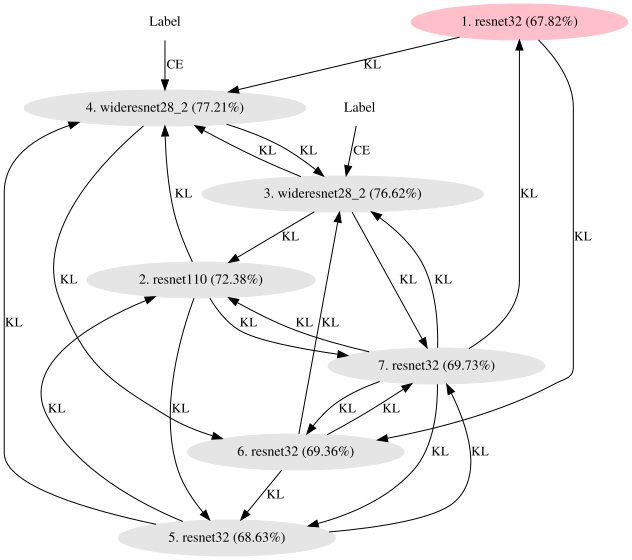

In [3]:
def build_graph_viz(trial: optuna.trial.FrozenTrial, main_model: str) -> Digraph:
    params    = trial.params
    num_nodes = trial.user_attrs["num_nodes"]

    # teacher node detection (no incoming edges)
    has_incoming = set()
    for i in range(num_nodes):
        if params.get(f"label_edge_{i}", False):
            has_incoming.add(i)
    for src in range(num_nodes):
        for tgt in range(num_nodes):
            if src != tgt and params.get(f"peer_{src}_{tgt}", False):
                has_incoming.add(tgt)
    teacher_nodes = set(range(num_nodes)) - has_incoming

    def nid(i):
        model_name = main_model if i == 0 else params.get(f"model_{i}", f"node{i}")
        acc = trial.user_attrs.get(f"best_acc_{i}")
        acc_str = f" ({acc:.2f}%)" if acc is not None else ""
        return f"{i+1}. {model_name}{acc_str}"

    G = Digraph(format="svg", engine="dot")

    # default: gray90 (ellipse)
    for i in range(num_nodes):
        G.node(nid(i), color='gray90', fillcolor='gray90', style='filled')
    # node 0: pink
    G.node(nid(0), color='pink', fillcolor='pink', style='radial')

    # label edges
    for i in range(num_nodes):
        if params.get(f"label_edge_{i}", False):
            G.edge(str(i), nid(i), label="CE", fontsize="13")
            G.node(str(i), label="Label", color='white', style='filled')

    # peer KL edges
    for src in range(num_nodes):
        for tgt in range(num_nodes):
            if src != tgt and params.get(f"peer_{src}_{tgt}", False):
                G.edge(nid(src), nid(tgt), label="KL", fontsize="13")

    # teacher nodes: lightblue (override at the end)
    for i in teacher_nodes:
        G.node(nid(i), color='lightblue', fillcolor='lightblue', style='radial')

    return G


TOP_N = 5
top_trials = sorted(complete, key=lambda t: t.value, reverse=True)[:TOP_N]

for rank, trial in enumerate(top_trials):
    print(f"--- Rank {rank+1}  trial #{trial.number}  val_acc={trial.value:.4f} ---")
    display(build_graph_viz(trial, MAIN_MODEL))